# KS 4 — What the knobs actually do

Estimated time: 25–30 minutes

## Prerequisites
- **KS 3** — in particular the resolution constraint ($\Delta x \sim \sigma_r$) and the
  fact that `pmhc_mode` decides whether a centred contact exists at all.

## Learning aims
- **Primary scientific aim**: test the three predictions you made in KS 1.
- **Secondary modelling aim**: recognise when a parameter appears to "do nothing"
  because its *term* is switched off, rather than because the model is insensitive.

## Success criteria
- You can explain why raising rigidity κ shrinks the Monte Carlo step size, and why
  that makes `accept_rate` a poor progress indicator.
- You can name the one parameter change that would falsify the kinetic-segregation
  hypothesis, and say what the model does when you make it.

In [1]:
import tempfile

import matplotlib.pyplot as plt
import numpy as np

from ks_tutorial import COLOR_CD45, COLOR_TCR, load_frame, load_frame_meta, run_ks

# The KS 3 regime: dx = 500/64 = 7.8 nm, close enough to sigma_r for the pMHC
# influence field to survive. n_steps is pinned so every comparison below does
# the same amount of Monte Carlo work.
BASE = dict(
    time_sec=1.0,
    n_steps=1500,
    rigidity_kT=5.0,
    patch_size=500.0,
    grid_size=64,
    n_tcr=40,
    n_cd45=400,   # enough CD45 that the in-disc fraction is a stable statistic
    pmhc_mode="inner_circle",
    n_pmhc=40,
    pmhc_radius=62.5,
)
SEEDS = (42, 43, 44, 45)


def cd45_retention(**overrides):
    # Fraction of CD45 inside the contact disc at the end, over the fraction at
    # the start. < 1 means CD45 was expelled; ~1 indifferent; > 1 drifted in.
    # Deliberately NOT depletion_width_nm -- see "Why not the built-in metric?".
    p = {**BASE, **overrides}
    ratios = []
    for seed in SEEDS:
        with tempfile.TemporaryDirectory() as rd:
            run_ks(rd, dump_frames=True, dump_interval=p["n_steps"], seed=seed, **p)
            m = load_frame_meta(rd)
            _, _, cd_start = load_frame(rd, 0, m)
            _, _, cd_end = load_frame(rd, 1, m)
        ctr, R = m["patch_nm"] / 2, p["pmhc_radius"]
        f0 = (np.hypot(*(cd_start - ctr).T) < R).mean()
        f1 = (np.hypot(*(cd_end - ctr).T) < R).mean()
        ratios.append(f1 / f0)
    return float(np.mean(ratios)), float(np.std(ratios))


def scan(param, values, **overrides):
    out = [cd45_retention(**{**overrides, param: v}) for v in values]
    return np.array([m for m, _ in out]), np.array([sd for _, sd in out])


def diagnostics_for(param, values):
    return [run_ks(**{**BASE, param: v, "seed": SEEDS[0]})["diagnostics"] for v in values]


print("base configuration:", {k: BASE[k] for k in ("patch_size", "grid_size", "n_steps")})

base configuration: {'patch_size': 500.0, 'grid_size': 64, 'n_steps': 1500}


## Why not the built-in metric?

Everything below measures **CD45 retention** — the fraction of CD45 still inside the
contact disc at the end, divided by the fraction at the start. Below 1 means CD45 was
expelled.

`depletion_width_nm` would be the obvious choice, and it is the wrong one here. In this
setup TCRs are seeded on top of pMHC, which sit in a central disc, so the TCR and CD45
radial distributions are *already* well separated at step 0. The metric starts near its
final value and barely moves, which means it mostly reports the initial condition rather
than anything the simulation did. Sweeping a parameter against it yields a flat line
with a large spread — not because the physics is insensitive, but because the
measurement is saturated.

The retention ratio is normalised by its own starting value, so the seeding cancels and
only the change is left. Choosing an observable that can actually move is part of
designing the experiment, not an afterthought.

## Prediction 1 — membrane rigidity κ

From KS 1: a stiffer membrane resists the deformation that TCR binding needs, so
exclusion should weaken as κ rises.

There is a second, less obvious effect. The time step is calibrated from the physics as
$\Delta t \propto \Delta x^2 / (D_h\,\kappa)$, so **$\Delta t \cdot \kappa$ is
constant** — and the proposed height move is
$\sqrt{2 D_h \Delta t} \propto 1/\sqrt{\kappa}$. Stiffening the membrane silently
shrinks the sampler's step size. Check both below.

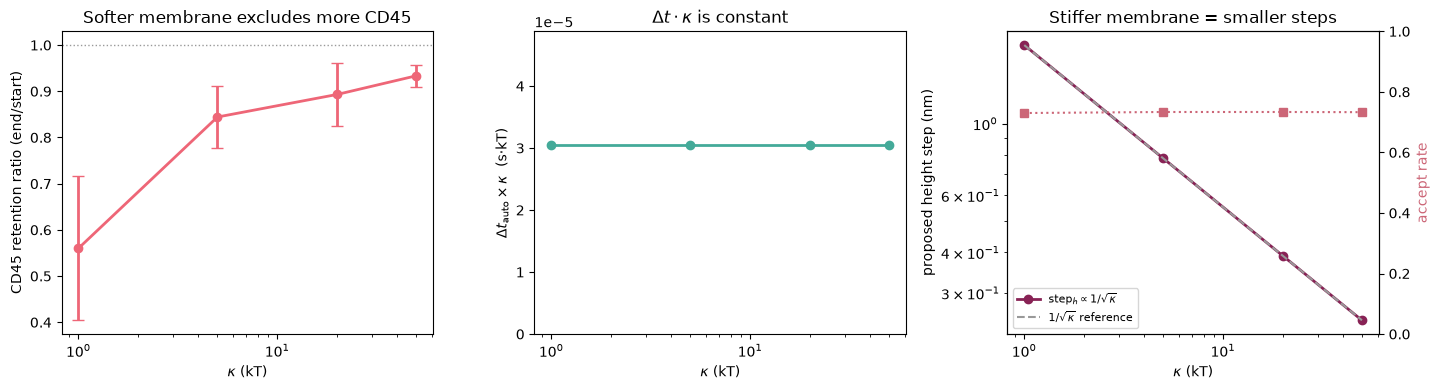

dt_auto * kappa : 3.051758e-05 .. 3.051758e-05  (spread 0.000 %)
accept rate     : 0.730 .. 0.734


In [2]:
KAPPAS = np.array([1.0, 5.0, 20.0, 50.0])
w_mean, w_sd = scan("rigidity_kT", KAPPAS)
diags = diagnostics_for("rigidity_kT", KAPPAS)

dt_auto = np.array([d["dt_auto_seconds"] for d in diags])
step_h = np.array([d["step_size_h_nm"] for d in diags])
accept = np.array([d["accept_rate"] for d in diags])

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))
axes[0].errorbar(KAPPAS, w_mean, yerr=w_sd, marker="o", capsize=4, color=COLOR_TCR, lw=2)
axes[0].set_xscale("log"); axes[0].set_xlabel(r"$\kappa$ (kT)")
axes[0].axhline(1.0, color="#999", lw=1, ls=":")
axes[0].set_ylabel("CD45 retention ratio (end/start)")
axes[0].set_title("Softer membrane excludes more CD45")

axes[1].plot(KAPPAS, dt_auto * KAPPAS, "o-", color="#44AA99", lw=2)
axes[1].set_xscale("log"); axes[1].set_xlabel(r"$\kappa$ (kT)")
axes[1].set_ylabel(r"$\Delta t_{\rm auto} \times \kappa$  (s$\cdot$kT)")
axes[1].set_title(r"$\Delta t \cdot \kappa$ is constant")
axes[1].set_ylim(0, float(np.max(dt_auto * KAPPAS)) * 1.6)

axes[2].plot(KAPPAS, step_h, "o-", color="#882255", lw=2, label=r"step$_h \propto 1/\sqrt{\kappa}$")
axes[2].plot(KAPPAS, step_h[0] / np.sqrt(KAPPAS / KAPPAS[0]), "--", color="#999",
             label=r"$1/\sqrt{\kappa}$ reference")
ax2b = axes[2].twinx()
ax2b.plot(KAPPAS, accept, "s:", color="#CC6677", label="accept rate")
ax2b.set_ylabel("accept rate", color="#CC6677"); ax2b.set_ylim(0, 1)
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_xlabel(r"$\kappa$ (kT)"); axes[2].set_ylabel("proposed height step (nm)")
axes[2].set_title("Stiffer membrane = smaller steps"); axes[2].legend(fontsize=8, loc="lower left")

plt.tight_layout(); plt.show()

prod = dt_auto * KAPPAS
print(f"dt_auto * kappa : {prod.min():.6e} .. {prod.max():.6e}  "
      f"(spread {100 * (prod.max() - prod.min()) / prod.mean():.3f} %)")
print(f"accept rate     : {accept.min():.3f} .. {accept.max():.3f}")

### What the middle panel means for your workflow

$\Delta t \cdot \kappa$ is constant to within rounding. So when you sweep κ at fixed
`time_sec`, you are **not** holding computational effort fixed — the number of sweeps
scales with κ. And when you pin `n_steps` instead (as we do here), you are not holding
*physical time* fixed.

There is no setting in which both are constant. Any κ sweep therefore has a confound,
and you have to choose which one you want. Say which in your methods.

## Prediction 3 — the falsification test

This is the sharpest experiment in the notebook. KS 1 claimed the mechanism depends on
a *size ordering*: CD45 (50 nm) must be taller than the TCR–pMHC bridge (13 nm). If it
were shorter, it would fit inside the contact and there would be nothing to exclude.

`--cd45_height` lets us simply invert the ordering. Predict the shape of the curve
before running: where should exclusion collapse?

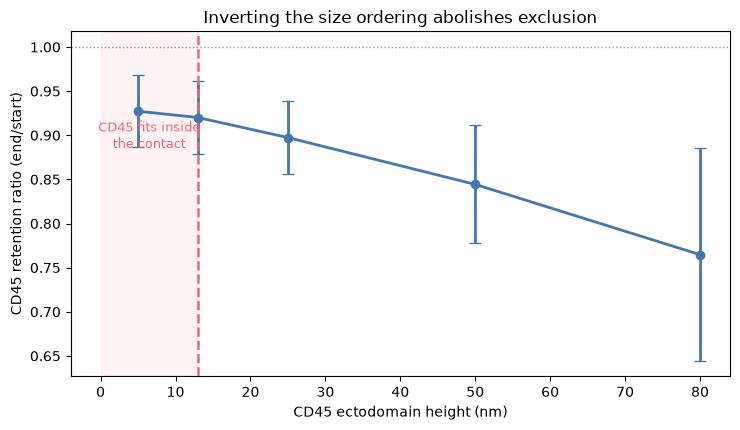

  cd45_height =   5.0 nm -> retention 0.927 +/- 0.041  <- fits inside the 13 nm bridge
  cd45_height =  13.0 nm -> retention 0.920 +/- 0.042  <- fits inside the 13 nm bridge
  cd45_height =  25.0 nm -> retention 0.897 +/- 0.041
  cd45_height =  50.0 nm -> retention 0.844 +/- 0.067
  cd45_height =  80.0 nm -> retention 0.765 +/- 0.120


In [3]:
HEIGHTS = np.array([5.0, 13.0, 25.0, 50.0, 80.0])
h_mean, h_sd = scan("cd45_height", HEIGHTS)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.errorbar(HEIGHTS, h_mean, yerr=h_sd, marker="o", capsize=4, lw=2, color=COLOR_CD45)
ax.axvline(13.0, color=COLOR_TCR, ls="--", lw=1.8)
ax.axvspan(0, 13.0, color=COLOR_TCR, alpha=0.08)
ax.text(6.5, ax.get_ylim()[1] * 0.9, "CD45 fits inside\nthe contact",
        ha="center", fontsize=9, color=COLOR_TCR)
ax.set_xlabel("CD45 ectodomain height (nm)")
ax.axhline(1.0, color="#999", lw=1, ls=":")
ax.set_ylabel("CD45 retention ratio (end/start)")
ax.set_title("Inverting the size ordering abolishes exclusion")
plt.tight_layout(); plt.show()

for hh, mm, ss in zip(HEIGHTS, h_mean, h_sd):
    flag = "  <- fits inside the 13 nm bridge" if hh <= 13.0 else ""
    print(f"  cd45_height = {hh:5.1f} nm -> retention {mm:.3f} +/- {ss:.3f}{flag}")

## Prediction 2 — and a lesson about measurement

KS 1 asked what happens if you deepen the TCR–pMHC bond. Intuition says: stronger
binding, more contact, more exclusion.

Measured with `depletion_width_nm`, the answer is a flat line — the metric does not
move at all as `u_assoc` goes from 1 to 2000 kT. It is very tempting to conclude that
the model is insensitive to binding strength.

Measure the same runs with CD45 retention and the effect is plainly there. Run it.

In [4]:
U_VALUES = np.array([1.0, 20.0, 200.0, 2000.0])
u_mean, u_sd = scan("u_assoc", U_VALUES)
for uu, mm, ss in zip(U_VALUES, u_mean, u_sd):
    print(f"  u_assoc = {uu:7.1f} kT -> retention {mm:.3f} +/- {ss:.3f}")

# The well's WIDTH, not its depth, sets how far it can reach.
from ks_tutorial import ensure_potentials
lib = ensure_potentials()
print("\nTCR well strength vs separation (u_assoc=20, sigma_bind=3):")
for hh in (13, 16, 20, 25, 30, 40):
    print(f"   E_tcr({hh:2d} nm) = {lib.tcr_pmhc_potential(float(hh), 13.0, 20.0, 3.0):>11.3e} kT")

  u_assoc =     1.0 kT -> retention 0.862 +/- 0.058
  u_assoc =    20.0 kT -> retention 0.844 +/- 0.067
  u_assoc =   200.0 kT -> retention 0.703 +/- 0.163
  u_assoc =  2000.0 kT -> retention 0.643 +/- 0.149

TCR well strength vs separation (u_assoc=20, sigma_bind=3):
   E_tcr(13 nm) =  -2.000e+01 kT
   E_tcr(16 nm) =  -1.213e+01 kT
   E_tcr(20 nm) =  -1.315e+00 kT
   E_tcr(25 nm) =  -6.709e-03 kT
   E_tcr(30 nm) =  -2.129e-06 kT
   E_tcr(40 nm) =  -5.154e-17 kT


### The model was never the insensitive part

Retention falls monotonically as the well deepens: the bond really does pull the
membrane down and evict CD45, exactly as KS 1 predicted.

`depletion_width_nm` could not see it, for the reason given above — it was saturated by
the initial seeding, so there was no room left for a parameter to move it. Had we
stopped at the built-in metric, we would have published "the model is insensitive to
binding energy", and it would have been an artefact of our choice of ruler.

That said, the well's *reach* is genuinely limited, and the table below shows why. With
$\sigma_{m bind} = 3$ nm the attraction is already down to
$\sim 10^{-3}\,k_BT$ at 25 nm and $\sim 10^{-17}$ at 40 nm. So depth buys you a
stronger grip on a contact that already exists, but almost no ability to re-form one
that has been lost. Geometry ($h_0$, $\sigma_{m bind}$) governs *whether* the bond
acts; depth governs only *how hard* once it does.

Two takeaways, in order of importance:

1. **A null result is a statement about your measurement as much as your model.**
   Before concluding "parameter X does nothing", check that your observable is capable
   of moving at all — ideally by verifying it responds to something you are certain
   matters.
2. Note the growing error bars at large `u_assoc`. A deeper well makes the dynamics
   more strongly driven and the run-to-run spread larger, so the *same* number of seeds
   buys less precision. Effect size and noise often grow together.

## `binding_mode` — the one knob that changes the algorithm

`gaussian` (default) and `forced` are not two parameterisations of one mechanism; they
are different models.

- **`gaussian`** — the TCR well at each cell is scaled by a smooth pMHC influence field
  of range $\sigma_r$. Every TCR stays mobile. Nothing is pinned.
- **`forced`** — binary gating: a TCR standing on a cell containing pMHC is flagged
  *bound*, is then skipped in Phase 1 (immobile), and its cell's height is **frozen** at
  $h_0 = 13$ nm in Phase 2.

`forced` therefore holds the contact open by construction rather than by energetics.
That makes it far more robust to the resolution problem from KS 3 — but it also means
the contact is an input, not a result.

In [5]:
def disc_height(run_dir, meta, frame):
    hh, _, _ = load_frame(run_dir, frame, meta)
    n = hh.shape[0]
    yy, xx = np.mgrid[0:n, 0:n]
    return float(hh[np.hypot(xx - n / 2, yy - n / 2) < n / 8].mean())


print("                 contact disc height (nm)      depletion")
print("  binding_mode    start  ->  end               width (nm)")
mode_end = {}
for mode in ("gaussian", "forced"):
    p = {**BASE, "binding_mode": mode, "seed": 42}
    with tempfile.TemporaryDirectory() as rd:
        r = run_ks(rd, dump_frames=True, dump_interval=BASE["n_steps"], **p)
        m = load_frame_meta(rd)
        s, e = disc_height(rd, m, 0), disc_height(rd, m, 1)
    mode_end[mode] = e
    print(f"  {mode:<13}   {s:5.1f}  ->  {e:5.1f}              {r['depletion_width_nm']:7.1f}")

                 contact disc height (nm)      depletion
  binding_mode    start  ->  end               width (nm)


  gaussian         13.0  ->   46.6                151.2


  forced           13.0  ->   24.9                147.7


## Scientific checkpoint

1. You sweep κ over 1–50 kT at fixed `time_sec` and find depletion falls. How much of
   that is physics and how much is the sampler taking smaller steps? Design a control.
2. A colleague reports that `u_assoc` has no effect and concludes the TCR bond is
   irrelevant to segregation. What is wrong with the inference?
3. Which of these two would you use to *predict* the effect of a drug that shortens
   CD45 — `gaussian` or `forced`? Why?

<details>
<summary>Check yourself</summary>

1. Pin `n_steps` instead of `time_sec` so every κ does equal Monte Carlo work, and
   check whether the trend survives. Better still, report both — if they disagree, the
   trend is partly a sampling artefact. `step_size_h_nm` in the diagnostics tells you
   directly how much the proposal scale moved.
2. It confuses "this parameter" with "this mechanism". The bond matters enormously —
   through $h_0$ and $\sigma_{\rm bind}$, which set where and how far it acts. Depth is
   simply not the limiting quantity in the regime being sampled, because the well is
   already at ~0 wherever the membrane sits.
3. `gaussian`. `forced` freezes bound cells at $h_0$ by fiat, so the contact zone is
   imposed rather than earned — it cannot tell you whether a shorter CD45 would let
   contact form, because contact is assumed. `gaussian` lets the energetics decide,
   which is what you want from a prediction.
</details>

## Where to go next

**KS 5 — Observables and pitfalls**: the eight metrics, what each is blind to, and the
CLI traps that silently change what you ran.

In [6]:
# Final check: the quantitative claims this notebook makes.
assert np.ptp(dt_auto * KAPPAS) / np.mean(dt_auto * KAPPAS) < 1e-6,     "dt_auto * kappa should be constant"
assert w_mean[0] < w_mean[-1], "a softer membrane must exclude CD45 more than a stiff one"
assert h_mean[0] > h_mean[-1], "a taller CD45 must be excluded more strongly than a short one"
assert h_mean[0] > 0.9, "CD45 shorter than the bridge should barely be excluded"
assert u_mean[0] > u_mean[-1], "a deeper well should exclude more, on a responsive metric"
assert mode_end["forced"] < mode_end["gaussian"],     "forced mode pins the contact, so its disc should stay closer to h0"
print("[KS_4 self-check OK]")

[KS_4 self-check OK]
